## IMPACT OF UNIVERSAL PRIMARY EDUCATION (UPE) ENROLLMENT IN UGANDA

## 1. Background

31,000 pupils drop out of school daily in Uganda, and 60% of households cite the cost of schooling as the main reason for dropout. The World Bank reports that 40% of families in Uganda are most worried about the cost of education more than any other financial concern.  

In Uganda, the government introduced Universal Primary Education (UPE) in 1997 to increase access to basic education and Universal Secondary Education (USE) in 2007 by reducing financial barriers for households,though the reality on ground is starkly different.
 
This project analyzes whether UPE had a measurable impact on primary school enrollment in Uganda using historical enrollment data.
Before UPE, many children in Uganda were unable to attend school because of costs such as tuition, uniforms, books, and transport. Although UPE aimed to provide free primary education, it is important to evaluate whether the policy significantly improved enrollment levels over time.

## 2. Objective
The objective of this project is to determine whether the introduction of UPE in 1997 increased primary school enrollment in Uganda.

## 3. Research Hypothesis

**Null Hypothesis (H₀):**
There is no significant difference in Uganda’s primary school enrollment before and after 1997.

**Alternative Hypothesis (H₁):**
Uganda’s primary school enrollment significantly increased after the introduction of UPE in 1997.

## 4. Data and Methods Used
The project uses a dataset from https://ourworldindata.org/financing-education containing net primary school enrollment rates for selected countries. The data was filtered for Uganda and analyzed from 1950 to the latest available year.

**Methods used:**
- Data filtering for Uganda
- Line graph of enrollment trends
- Comparison of pre-1997 and post-1997 enrollment levels
- Statistical hypothesis testing (t-test)

## 5. Expected Findings
If enrollment increased significantly after 1997,this would suggest that reducing education costs through UPE improved school access. A positive trend line after 1997 would support the effectiveness of the policy.

## 6. Significance of the Study
This study helps policymakers understand whether free education policies improve access to schooling. It may also guide future investments in education quality, retention, and household support programs in Uganda.




## DATA LOADING

In [53]:
##Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [54]:
df = pd.read_csv(r'C:\Users\sopiy\Downloads\primary-enrollment-selected-countries\primary-enrollment-selected-countries.csv')

## EXPLORATORY DATA ANALYSIS (EDA)

In [55]:
##Checking the size of the dataset
df.shape


(9084, 4)

In [56]:
##Checking the Column data
df.columns

Index(['Entity', 'Code', 'Year', 'Net enrolment rate in primary education'], dtype='object')

In [57]:
##Checking the first five rows of the dataset
df.head()

,Entity,Code,Year,Net enrolment rate in primary education
0,Afghanistan,AFG,1820,0.0
1,Afghanistan,AFG,1825,0.0
2,Afghanistan,AFG,1830,0.0
3,Afghanistan,AFG,1835,0.0
4,Afghanistan,AFG,1840,0.0


In [58]:
##Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9084 entries, 0 to 9083
Data columns (total 4 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Entity                                   9084 non-null   object 
 1   Code                                     8774 non-null   object 
 2   Year                                     9084 non-null   int64  
 3   Net enrolment rate in primary education  9084 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 284.0+ KB


In [59]:
# Checking for missing and duplicated values
print(f'\nMissing values: {df.isna().sum().sum()}')
print(f'Duplicated values: {df.duplicated().sum()}')


Missing values: 310
Duplicated values: 0


In [60]:
## Filtering the data to only display Uganda for the first 5 rows
uganda = df[df["Entity"] == "Uganda"].copy()
uganda.head()

,Entity,Code,Year,Net enrolment rate in primary education
8441,Uganda,UGA,1820,0.0
8442,Uganda,UGA,1825,0.0
8443,Uganda,UGA,1830,0.0
8444,Uganda,UGA,1835,0.0
8445,Uganda,UGA,1840,0.0


## TESTING THE HYPOTHESES

Expected Interpretation

If p < 0.05
UPE significantly improved enrollment.

If p > 0.05
No statistical evidence of improvement.

In [61]:
##before and after 1997 as a cutoff for testing policy impact on enrollment. UPE was launched in 1997
before = uganda[uganda["Year"] < 1997]["Net enrolment rate in primary education"].dropna()

after = uganda[uganda["Year"] >= 1997]["Net enrolment rate in primary education"].dropna()


In [62]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -26.111620737782456
P-value: 1.965758426142607e-26


### The T-Statistic Result
measures how large the difference is between the two groups 
t=−26.11 is a very large magnitude

meaning the difference between pre-1997 and post-1997 enrollment is extremely strong statistically.

The negative value means that the enrollment after 1997 is higher than before 1997


### The P-Value Result
is 1.97 × 10⁻²⁶= 0.0000000000000000000000000197  and is smaller than 0.05

UPE had a statistically significant positive impact on primary school enrollment in Uganda

Therefore, the null hypothesis (H₀) was rejected.

## DATA VISUALIZATION

In [63]:
## Filtering the data to only display the Country Uganda from the year 1930 to 2017
uganda = df[
    (df["Entity"] == "Uganda") &
    (df["Year"] >= 1930)
]
print(uganda)

      Entity Code  Year  Net enrolment rate in primary education
8463  Uganda  UGA  1930                                 2.750000
8464  Uganda  UGA  1935                                 3.540000
8465  Uganda  UGA  1940                                 7.290000
8466  Uganda  UGA  1945                                16.830000
8467  Uganda  UGA  1950                                25.870000
8468  Uganda  UGA  1955                                34.910000
8469  Uganda  UGA  1960                                39.000000
8470  Uganda  UGA  1965                                53.330000
8471  Uganda  UGA  1970                                30.240000
8472  Uganda  UGA  1975                                35.020000
8473  Uganda  UGA  1980                                39.000000
8474  Uganda  UGA  1986                                55.567310
8475  Uganda  UGA  2009                                94.645830
8476  Uganda  UGA  2010                                91.119170
8477  Uganda  UGA  2011  

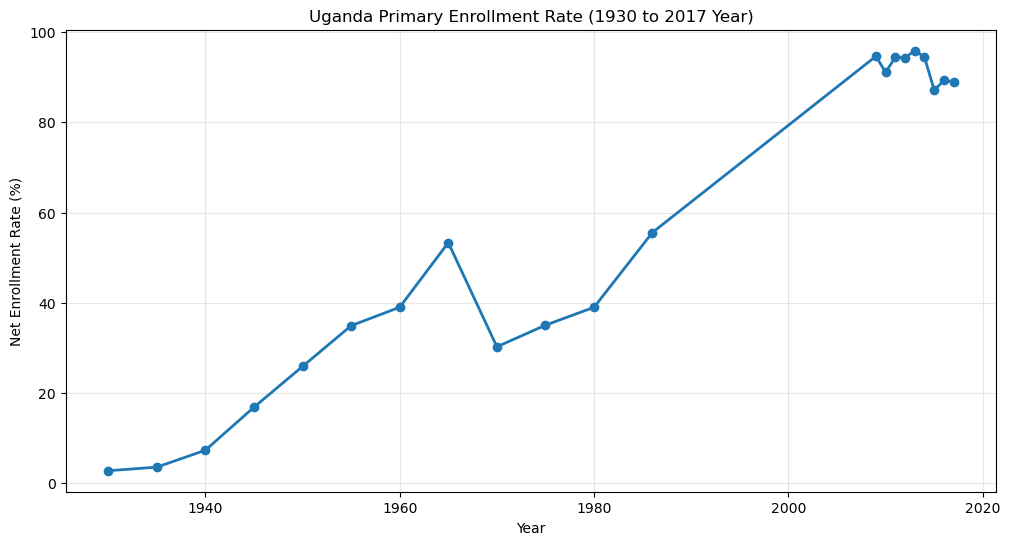

In [64]:
# Plot enrollment trend
plt.figure(figsize=(12,6))
plt.plot(
    uganda["Year"],
    uganda["Net enrolment rate in primary education"],
    marker="o",
    linewidth=2
)

plt.title("Uganda Primary Enrollment Rate (1930 to 2017 Year)")
plt.xlabel("Year")
plt.ylabel("Net Enrollment Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

The line graph shows that Uganda’s enrollment rate increased over time, especially after UPE indicating improved access to primary education.

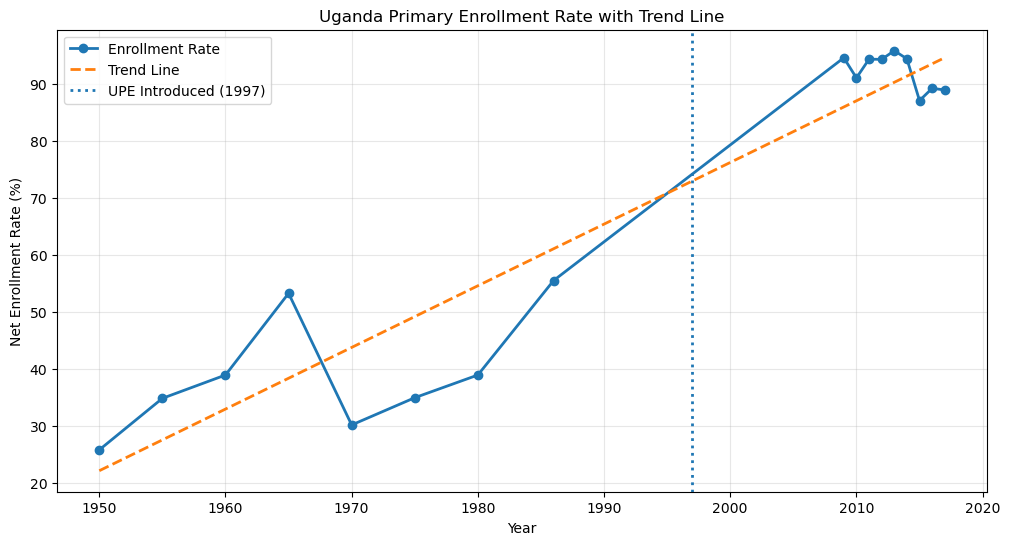

Trend Line Equation: y = 1.0814x + -2086.60


In [72]:
# Filter Uganda data from 1950 onward
uganda = df[
    (df["Entity"] == "Uganda") &
    (df["Year"] >= 1950)
].dropna(subset=["Net enrolment rate in primary education"])

# X and Y values
x = uganda["Year"]
y = uganda["Net enrolment rate in primary education"]

# Calculate trend line (line of best fit)
m, b = np.polyfit(x, y, 1)

# Plot line graph
plt.figure(figsize=(12,6))
plt.plot(x, y, marker="o", linewidth=2, label="Enrollment Rate")

# Plot trend line
plt.plot(x, m*x + b, linestyle="--", linewidth=2, label="Trend Line")

# Mark UPE year
plt.axvline(1997, linestyle=":", linewidth=2, label="UPE Introduced (1997)")

# Labels
plt.title("Uganda Primary Enrollment Rate with Trend Line")
plt.xlabel("Year")
plt.ylabel("Net Enrollment Rate (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Print equation of trend line
print(f"Trend Line Equation: y = {m:.4f}x + {b:.2f}")

The trend line shows a positive upward slope,indicating that Uganda’s primary school enrollment generally increased over the study period. This supports the conclusion that education access improved over time especially after the introduction of UPE.

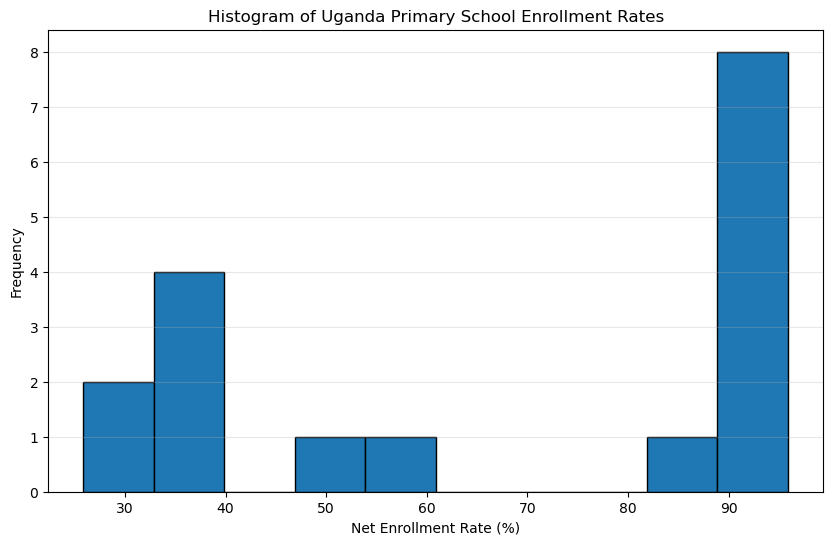

In [74]:

# Filter Uganda data from 1950 onwards
uganda = df[
    (df["Entity"] == "Uganda") &
    (df["Year"] >= 1950)
]

# Select enrollment values
enrollment = uganda["Net enrolment rate in primary education"].dropna()

# Create histogram
plt.figure(figsize=(10,6))
plt.hist(enrollment, bins=10, edgecolor="black")

# Labels and title
plt.title("Histogram of Uganda Primary School Enrollment Rates")
plt.xlabel("Net Enrollment Rate (%)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

The histogram shows the frequency distribution of Uganda’s primary school enrollment rates. 
Most observations are concentrated in the higher enrollment ranges,suggesting that Uganda experienced improved school participation over time,particularly after education access reforms.

## 7. Conclusion
This project examined the impact of Universal Primary Education (UPE) on primary school enrollment in Uganda using historical net enrollment data. 

Statistical analysis produced a very small p-value and a large t-statistic, leading to rejection of the null hypothesis. These results indicate a statistically significant increase in enrollment after the introduction of UPE in 1997. 

The findings suggest that reducing financial barriers through free primary education played an important role in expanding access to schooling in Uganda.

## 8. Limitations

- The dataset measures enrollment rates, not direct dropout rates, attendance, completion, or learning outcomes.
- Although enrollment increased after 1997, other factors may also have contributed, such as population growth, donor support, school construction, or economic changes.
- The dataset focuses on national-level trends and may not capture regional differences, gender gaps, or rural–urban disparities within Uganda.
- Higher enrollment does not necessarily mean improved education quality, teacher availability, or student performance.